In [191]:
# Autorelaode all modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import pandas as pd 
from climada.entity import LitPop

## Generate spatial maps of exposure data

In [3]:
from climada.util.api_client import Client
from climada.entity import Exposures
import matplotlib.pyplot as plt

def get_country_exposure_via_api(country_name, subregion_bounds=None):
    print("Initializing CLIMADA Data Client...")
    client = Client()
    
    # Fetch LitPop data from CLIMADA API
    print(f"Downloading/Loading {country_name} exposure data (this may take a moment)...")
    exp_country = client.get_litpop(country=country_name)
    
    # Subregion filtering
    if subregion_bounds is not None:
        lat_min, lat_max, lon_min, lon_max = subregion_bounds
        print(f"Filtering for subregion: {subregion_bounds}...")
        
        # geometry.y for Latitude and geometry.x for Longitude
        subset_gdf = exp_country.gdf[
            (exp_country.gdf.geometry.y >= lat_min) & 
            (exp_country.gdf.geometry.y <= lat_max) & 
            (exp_country.gdf.geometry.x >= lon_min) & 
            (exp_country.gdf.geometry.x <= lon_max)
        ]
        
        # Create a new Exposures object from the subset
        exp_country = Exposures(subset_gdf)

    exp_country.check()
    
    return exp_country

In [5]:
# Load it
portfolio_tw = get_country_exposure_via_api("TAIWAN")
portfolio_USA = get_country_exposure_via_api("USA")
portfolio_florida = get_country_exposure_via_api("USA", [24.5, 31.0, -87.6, -80.0])

Initializing CLIMADA Data Client...
Downloading/Loading TAIWAN exposure data (this may take a moment)...
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 31.0, -87.6, -80.0]...


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


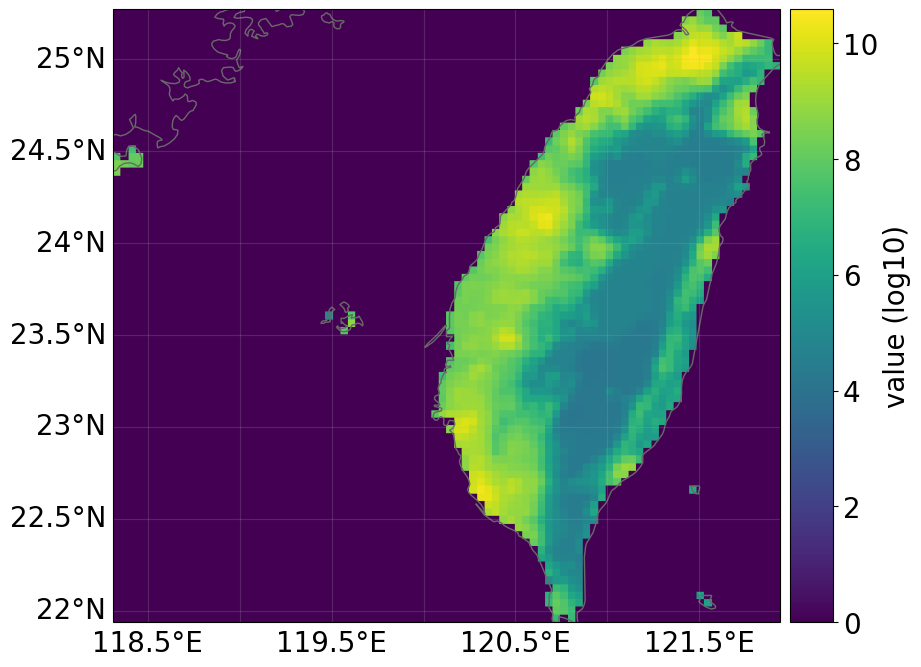

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


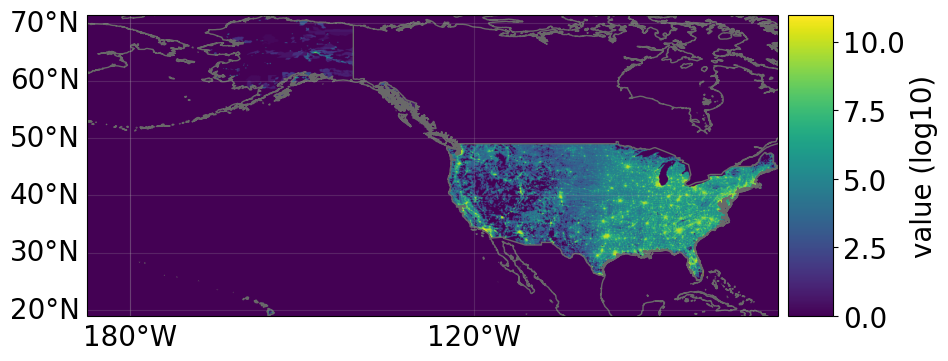

/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/climada/util/coordinates.py:3130: FutureWarning: The `drop` keyword argument is deprecated and in future the only supported behaviour will match drop=False. To silence this warning and adopt the future behaviour, stop providing `drop` as a keyword to `set_geometry`. To replicate the `drop=True` behaviour you should update your code to
`geo_col_name = gdf.active_geometry_name; gdf.set_geometry(new_geo_col).drop(columns=geo_col_name).rename_geometry(geo_col_name)`.
  df_poly.set_geometry(


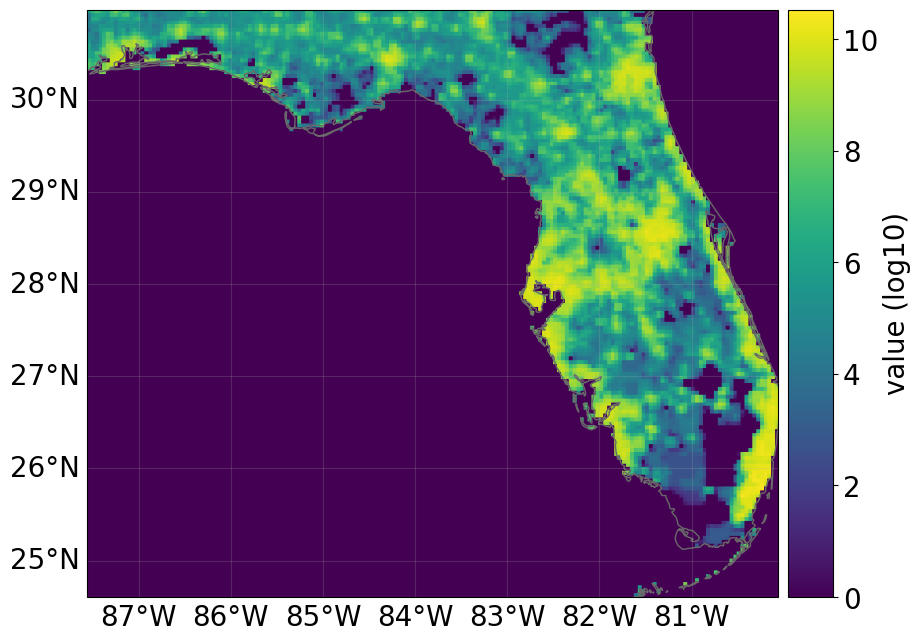

In [6]:
portfolio_tw.plot_raster()
plt.show()
portfolio_USA.plot_raster()
plt.show()
portfolio_florida.plot_raster()
plt.show()

In [23]:
import pandas as pd
import numpy as np

def construction_type_heuristic(values, seed=42):
    # Using a sigmoid function that assigns a Masory probability based on value 
    threshold = 1e6  
    steepness = 1e-7
    prob_masonry = 1 / (1 + np.exp(-steepness * (values - threshold)))

    np.random.seed(seed)
    rand_vals = np.random.rand(len(values))
    construction_types = np.where(rand_vals < prob_masonry, 'Masonry', 'Frame') 

    return construction_types


    

def convert_to_loss_model_format(climada_exposure):
    # Extract the raw GeoDataFrame from CLIMADA
    gdf = climada_exposure.gdf
    
    num_locs = len(gdf)
    lats = gdf.geometry.y.values
    lons = gdf.geometry.x.values
    
    values = gdf['value'].values
    
    # Add construction types based on heuristic
    construction_types = construction_type_heuristic(values)
    constructions = construction_types

    # Create DataFrame
    df = pd.DataFrame({
        'location_id': range(1, num_locs + 1),
        'latitude': lats,
        'longitude': lons,
        'tiv': values.round(2), # Total Insured Value
        'construction': constructions
    })
    
    return df

# Test 
my_loss_model_df = convert_to_loss_model_format(portfolio_tw)
print(my_loss_model_df.head())

   location_id   latitude   longitude         tiv construction
0            1  22.062500  121.520833   956414.30      Masonry
1            2  22.020833  121.562500  1113794.07        Frame
2            3  22.645833  121.479167  2856572.59        Frame
3            4  23.520833  120.104167        0.00        Frame
4            5  23.479167  120.062500        0.00      Masonry


Text(0.5, 1.0, 'Asset Locations with Size Proportional to TIV')

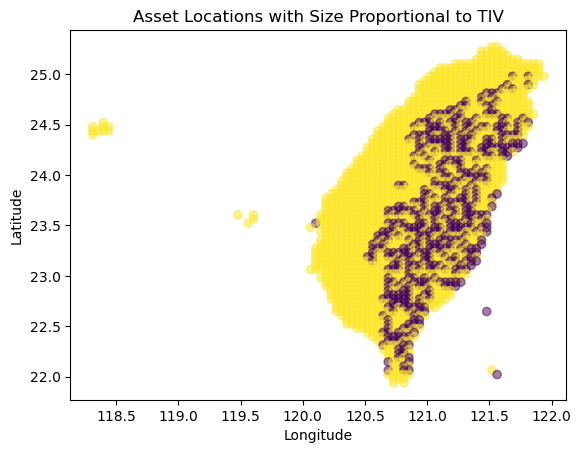

In [25]:
plt.scatter(my_loss_model_df['longitude'], my_loss_model_df['latitude'], c=my_loss_model_df['construction'].astype('category').cat.codes, alpha=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Asset Locations with Size Proportional to TIV')

In [26]:
# Import functions from src directory (src is ../src)
import sys
import pandas as pd
import numpy as np
sys.path.append('../src')

from download_TC_data import download_storm_forecast, extract_gzip
from preprocess_TC_data import clean_track_data, clean_track_data2
from utils import track_interpolation, cyclone_velocity, cyclone_bearing, extract_past_trajectory, extract_future_trajectory, prepare_track_data
from visualization import make_trajectory_animation, plot_trajectory
from generate_exposure import get_country_exposure_via_api, convert_to_loss_model_format
from wind_fields import get_heuristic_rmw
from loss import portfolio_damage_model, impact_tc_A_deck


In [40]:
# Download and extract storm forecast data
forecast_path = extract_gzip(download_storm_forecast(2018, 'al', '14', deck='a'))
# Load and clean the data 
df_forcast = clean_track_data2(forecast_path, is_best_track=False)
df_OFCL = df_forcast[df_forcast['TECH'] == 'OFCL'].copy()

housing_portfolio = convert_to_loss_model_format(get_country_exposure_via_api("USA", [24.5, 35.0, -95.6, -80.0]))

# Calculate losses for all timestamps in the "trusted models"
trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']
index = df_OFCL['timestamp'].unique()
future_loss = pd.DataFrame(index=index, columns=trusted_models)
past_loss = pd.DataFrame(index=index, columns=trusted_models)
history_aware_future_loss = pd.DataFrame(index=index, columns=trusted_models)


for timestamp in df_OFCL['timestamp'].unique():
    past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp=timestamp)
    
    # Map past damages to their corresponding models
    past_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if history_avail[model_idx] == 1:
            past_damage_total = past_damages[past_idx]['damage'].sum()
            #print(f"Timestamp: {timestamp}, Model: {model}, Past Damage: {past_damage_total}")
            past_loss.loc[timestamp, model] = past_damage_total
            past_idx += 1

    # Map future damages to their corresponding models
    future_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if future_avail[model_idx] == 1:
            future_damage_total = future_damages[future_idx]['damage'].sum()
            future_loss.loc[timestamp, model] = future_damage_total
            future_idx += 1

    # Hisoty aware future loss estimation
    haw_future_idx = 0
    for model_idx, model in enumerate(trusted_models):
        if future_avail[model_idx] == 1 and history_avail[model_idx] == 1:
            
            # find corresponding indices in the past/future lists
            p_idx = int(np.sum(history_avail[:model_idx+1]) - 1)
            f_idx = int(np.sum(future_avail[:model_idx+1]) - 1)

            # elementwise max between past and future damages per location, then sum
            combined_damage_total = pd.concat(
                [past_damages[p_idx]['damage'], future_damages[f_idx]['damage']],
                axis=1
            ).max(axis=1).sum()
            history_aware_future_loss.loc[timestamp, model] = combined_damage_total
            haw_future_idx += 1
print("Loss calculation completed.")


Year is 2018. Checking ARCHIVE source...


91it [00:00, 119.26it/s]
/Users/wirths/Documents/Private/NatCat/notebooks/../src/preprocess_TC_data.py:67: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, names=col_names, sep=",", skipinitialspace=True, on_bad_lines='warn')


Downloaded to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat
Looking for TECH column with value 'OFCL'
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 35.0, -95.6, -80.0]...


/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/homebrew/Caskroom/miniforge/base/envs/NatCat/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


Loss calculation completed.


/var/folders/wx/t338ck_s4qz_jg5cr9mg00hc0000gn/T/ipykernel_3310/1205733655.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cols = plt.cm.get_cmap('tab10', len(trusted_models))


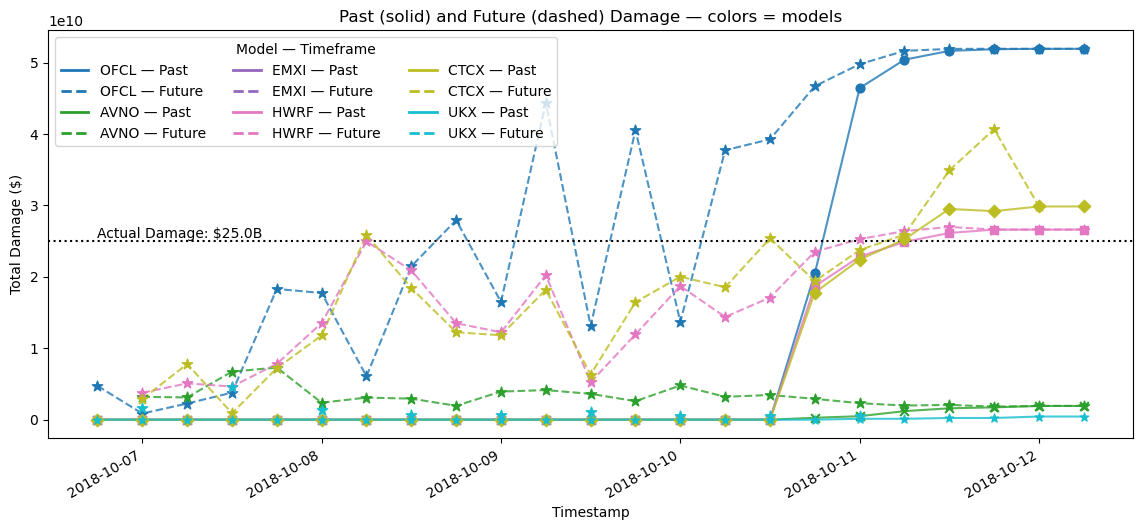

In [41]:
# Visualize the results: colored lines for each model (solid = past, dashed = future)
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,6))
cols = plt.cm.get_cmap('tab10', len(trusted_models))
markers = ['o','x','^','s','D','*']

# Plot colored lines for each model: solid = past, dashed = future.
for i, model in enumerate(trusted_models):
    color = cols(i)
    ax.plot(past_loss.index, past_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='-')
    #ax.plot(future_loss.index, future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    ax.scatter(past_loss.index, past_loss[model], color=color, marker=markers[i % len(markers)], s=40, zorder=3)
    #ax.scatter(future_loss.index, future_loss[model], color=color, marker='x', s=50, zorder=3)
    ax.plot(history_aware_future_loss.index, history_aware_future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    ax.scatter(history_aware_future_loss.index, history_aware_future_loss[model], color=color, marker='*', s=60, zorder=3)

    # ax.plot(past_loss.index, past_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='-')
    # ax.plot(future_loss.index, past_loss[model]+future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
    # ax.scatter(past_loss.index, past_loss[model], color=color, marker=markers[i % len(markers)], s=40, zorder=3)
    # ax.scatter(future_loss.index, past_loss[model]+future_loss[model], color=color, marker='x', s=50, zorder=3)

# Single aggregated legend: each entry shows model color + linestyle for past/future
handles = []
labels = []
for i, model in enumerate(trusted_models):
    color = cols(i)
    handles.append(Line2D([0],[0], color=color, lw=2, linestyle='-'))
    labels.append(f"{model} — Past")
    handles.append(Line2D([0],[0], color=color, lw=2, linestyle='--'))
    labels.append(f"{model} — Future")

ax.legend(handles, labels, title='Model — Timeframe', ncol=3, loc='upper left', bbox_to_anchor=(0,1))
ax.axhline(y=25.0e9, color='k', linestyle=':', label='Actual Damage')
ax.text(future_loss.index[0], 25.0e9, 'Actual Damage: $25.0B', color='k', fontsize=10, va='bottom', ha='left')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Total Damage ($)')
ax.set_title('Past (solid) and Future (dashed) Damage — colors = models')
fig.autofmt_xdate()
plt.show()

In [164]:
# import tqdm
import tqdm

def TC_loss_prediction(forcast_list, portfolio, portfolio_bounds=None,return_data=False, plot_results=False, illustrate_time_evolution=False):
    """Full pipeline to predict damage of every a certain TC given forecast data on a given portfolio.
    
    Input:
        forcast_list: array: [year, basin, storm_number, deck_type]
        portfolio: String if LitPop via CLIMADA API or DataFrame in loss model format
        portfolio_bounds (optional): list of [lat_min, lat_max, lon_min, lon_max] to subset the portfolio
        return_data (optional): Boolean, if True return the loss dataframes
        plot_results (optional): Boolean, if True plot the results
        illustrate_time_evolution (optional): Boolean, if True create an animation of the storm trajectory and wind field evolution

    Returns:
        past_loss: DataFrame with past losses per model
        future_loss: DataFrame with future losses per model
        history_aware_future_loss: DataFrame with history aware future losses per model
    """

    year, basin, storm_number, deck_type = forcast_list

    # Check format is right 
    if type(year) != int:
        raise ValueError("Year must be an integer.")
    if type(basin) != str or basin not in ['al', 'ep', 'cp']:
        raise ValueError("Basin must be a string: 'al', 'ep', or 'cp'.")
    if type(storm_number) != str or len(storm_number) != 2 or not storm_number.isdigit():
        raise ValueError("Storm number must be a two-digit string, e.g., '14'.")
    if type(deck_type) != str or deck_type not in ['a', 'b']:
        raise ValueError("Deck type must be a string: 'a' or 'b'.")
    if deck_type == 'b':
        raise NotImplementedError("Deck type 'b' is not yet implemented for this workflow. Please refer to nb01 for deck 'b' processing.")
    
    # Download and extract storm forecast data
    forecast_path = extract_gzip(download_storm_forecast(year, basin, storm_number, deck=deck_type))
    # Load and clean the data
    df_forcast = clean_track_data2(forecast_path, is_best_track=False)
    df_OFCL = df_forcast[df_forcast['TECH'] == 'OFCL'].copy()

    if isinstance(portfolio, str):
        # Load portfolio via CLIMADA API
        if portfolio_bounds is not None:
            housing_portfolio = convert_to_loss_model_format(get_country_exposure_via_api(portfolio, portfolio_bounds))
        else:
            housing_portfolio = convert_to_loss_model_format(get_country_exposure_via_api(portfolio))
    elif isinstance(portfolio, pd.DataFrame):
        housing_portfolio = portfolio
    else:
        raise ValueError("Portfolio must be either a country name string or a DataFrame in loss model format.")
    
    
    
    # Calculate losses for all timestamps in the "trusted models"
    trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']
    index = df_OFCL['timestamp'].unique()
    future_loss = pd.DataFrame(index=index, columns=trusted_models)
    past_loss = pd.DataFrame(index=index, columns=trusted_models)
    history_aware_future_loss = pd.DataFrame(index=index, columns=trusted_models)

    print("Starting loss calculation...")
    for timestamp in tqdm.tqdm(df_OFCL['timestamp'].unique()):
        past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(df_forcast, housing_portfolio, timestamp=timestamp)
        
        # Map past damages to their corresponding models
        past_idx = 0
        for model_idx, model in enumerate(trusted_models):
            if history_avail[model_idx] == 1:
                past_damage_total = past_damages[past_idx]['damage'].sum()
                #print(f"Timestamp: {timestamp}, Model: {model}, Past Damage: {past_damage_total}")
                past_loss.loc[timestamp, model] = past_damage_total
                past_idx += 1

        # Map future damages to their corresponding models
        future_idx = 0
        for model_idx, model in enumerate(trusted_models):
            if future_avail[model_idx] == 1:
                future_damage_total = future_damages[future_idx]['damage'].sum()
                future_loss.loc[timestamp, model] = future_damage_total
                future_idx += 1

        # Hisoty aware future loss estimation
        haw_future_idx = 0
        for model_idx, model in enumerate(trusted_models):
            if future_avail[model_idx] == 1 and history_avail[model_idx] == 1:
                
                # find corresponding indices in the past/future lists
                p_idx = int(np.sum(history_avail[:model_idx+1]) - 1)
                f_idx = int(np.sum(future_avail[:model_idx+1]) - 1)

                # elementwise max between past and future damages per location, then sum
                combined_damage_total = pd.concat(
                    [past_damages[p_idx]['damage'], future_damages[f_idx]['damage']],
                    axis=1
                ).max(axis=1).sum()
                history_aware_future_loss.loc[timestamp, model] = combined_damage_total
                haw_future_idx += 1
    print("Loss calculation completed.")


    if plot_results:        
        # Visualize the results: colored lines for each model (solid = past, dashed = future)
        from matplotlib.lines import Line2D
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=(14,6))
        cols = plt.colormaps.get_cmap('tab10').resampled(len(trusted_models))
        markers = ['o','x','^','s','D','*']

        # Plot colored lines for each model: solid = past, dashed = future.
        for i, model in enumerate(trusted_models):
            color = cols(i)
            ax.plot(past_loss.index, past_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='-')
            ax.scatter(past_loss.index, past_loss[model], color=color, marker=markers[i % len(markers)], s=40, zorder=3)
            ax.plot(history_aware_future_loss.index, history_aware_future_loss[model], color=color, linewidth=1.5, alpha=0.8, linestyle='--')
            ax.scatter(history_aware_future_loss.index, history_aware_future_loss[model], color=color, marker='*', s=60, zorder=3)

        # Single aggregated legend: each entry shows model color + linestyle for past/future
        handles = []
        labels = []
        for i, model in enumerate(trusted_models):
            color = cols(i)
            handles.append(Line2D([0],[0], color=color, lw=2, linestyle='-'))
            labels.append(f"{model} — Past")
            handles.append(Line2D([0],[0], color=color, lw=2, linestyle='--'))
            labels.append(f"{model} — Future")

        ax.legend(handles, labels, title='Model — Timeframe', ncol=3, loc='upper left', bbox_to_anchor=(0,1))
        #ax.axhline(y=25.0e9, color='k', linestyle=':', label='Actual Damage')
        #ax.text(future_loss.index[0], 25.0e9, 'Actual Damage: $25.0B', color='k', fontsize=10, va='bottom', ha='left')
        ax.set_xlabel('Timestamp')
        ax.set_ylabel('Total Damage ($)')
        ax.set_title('Past (solid) and Future (dashed) Damage — colors = models')
        fig.autofmt_xdate()
        plt.show()
    
    if return_data:
        return past_loss, future_loss, history_aware_future_loss

    else:
        return None

Year is 2018. Checking ARCHIVE source...


91it [00:00, 113.18it/s]
/Users/wirths/Documents/Private/NatCat/notebooks/../src/preprocess_TC_data.py:67: DtypeWarning: Columns (30) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, header=None, names=col_names, sep=",", skipinitialspace=True, on_bad_lines='warn')


Downloaded to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat.gz
Extracted to /Users/wirths/Documents/Private/NatCat/src/../data/raw/aal142018.dat
Looking for TECH column with value 'OFCL'
Initializing CLIMADA Data Client...
Downloading/Loading USA exposure data (this may take a moment)...
Filtering for subregion: [24.5, 31.0, -87.6, -80.0]...
Starting loss calculation...


100%|██████████| 23/23 [00:18<00:00,  1.25it/s]

Loss calculation completed.


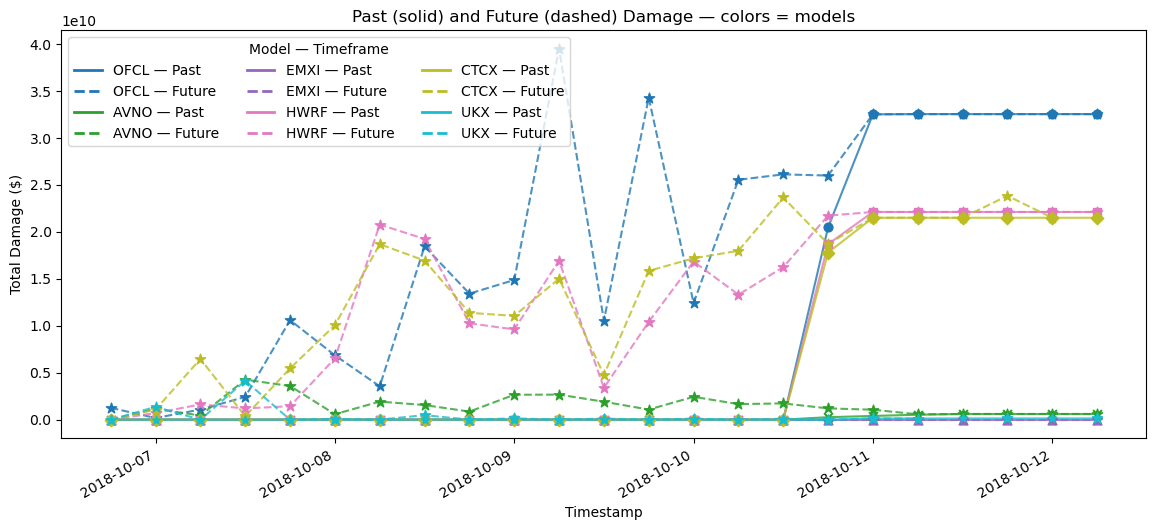

In [165]:
TC_loss_prediction([2018, 'al', '14', 'a'], "USA", portfolio_bounds= [24.5, 31.0, -87.6, -80.0], return_data=False, plot_results=True, illustrate_time_evolution=False)

In [192]:
def animate_storm_damage(df_forecast, portfolio,past_damages,history_avail, timestamps=None, save_path=None, fps=2, figsize=(14, 10), damage_model='OFCL'):
    """
    Create an animation of storm trajectories and evolving damage over time.
    
    Parameters:
    -----------
    df_forecast : DataFrame
        Forecast data containing all model predictions
    portfolio : Exposures object
        CLIMADA exposure/portfolio data (e.g., portfolio_florida)
    past_damages : list 
        List of past damages for all time steps 
    history_avial : list 
        Boolean list indicating if a histoy is availabel for model 
    timestamps : list, optional
        List of timestamps to animate. If None, uses all OFCL timestamps
    save_path : str, optional
        Path to save animation (e.g., 'storm_animation.mp4' or 'storm_animation.gif')
    fps : int, default=2
        Frames per second for the animation
    figsize : tuple, default=(14, 10)
        Figure size
    damage_model : str, default='OFCL'
        Which forecast model to use for damage visualization.
        Options: 'OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX'
        
    Returns:
    --------
    animation : matplotlib.animation.FuncAnimation
        The animation object
    """
    from matplotlib.animation import FuncAnimation
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from matplotlib.colors import LogNorm
    from scipy.interpolate import griddata
    import warnings
    
    # Suppress specific warnings
    warnings.filterwarnings('ignore', category=FutureWarning, module='climada')
    warnings.filterwarnings('ignore', category=UserWarning, module='cartopy')
    
    # Get timestamps if not provided
    if timestamps is None:
        df_OFCL = df_forecast[df_forecast['TECH'] == 'OFCL'].copy()
        timestamps = sorted(df_OFCL['timestamp'].unique())
    
    # Convert portfolio for damage calculation
    portfolio_converted = convert_to_loss_model_format(portfolio)
    
    # Import numpy
    import numpy as np
    
    
    # Setup plot with proper layout
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': ccrs.PlateCarree()})
    plt.subplots_adjust(top=0.95)
    
    # Markers and colors for models
    markers = ['o', 'x', '^', 's', 'D', '*']
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    trusted_models = ['OFCL', 'AVNO', 'EMXI', 'HWRF', 'CTCX', 'UKX']
    
    # Validate and get index of damage model
    if damage_model not in trusted_models:
        raise ValueError(f"damage_model must be one of {trusted_models}, got '{damage_model}'")
    damage_model_idx = trusted_models.index(damage_model)
    print(f"Using {damage_model} model for damage visualization")
    
    # Store colorbar reference to avoid accumulation
    cbar_ref = [None]
    
    def init():
        """Initialize the plot."""
        ax.clear()
        ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
        ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
        ax.set_extent([-90, -75, 15, 38], crs=ccrs.PlateCarree())
        ax.grid(alpha=0.3)
        return []
    
    def update(frame_num):
        """Update function for animation."""
        timestamp = timestamps[frame_num]
        
        # Remove old colorbar before clearing axes (colorbar is separate from axes)
        if cbar_ref[0] is not None:
            cbar_ref[0].remove()
            cbar_ref[0] = None
        
        # Clear previous frame
        ax.clear()
        
        # Add map features
        ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
        ax.add_feature(cfeature.OCEAN, facecolor='#e0f7fa')
        ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.STATES, linewidth=0.5, edgecolor='gray')
        
        # Overlay portfolio exposure
        cmap_exposure = plt.cm.viridis.copy()
        cmap_exposure.set_under('none')
        portfolio.plot_raster(axis=ax, cmap=cmap_exposure, alpha=0.4, vmin=1e-3)
        
        # Calculate damage at this timestamp
        past_damages, future_damages, history_avail, future_avail = impact_tc_A_deck(
            df_forecast, 
            portfolio_converted, 
            timestamp=timestamp
        )
        
        # Plot damage if available
        if history_avail[damage_model_idx] == 1:  # Check if selected model has data
            damage_data = past_damages[int(sum(history_avail[:damage_model_idx+1])) - 1].copy()
            damage_data_nonzero = damage_data[damage_data['damage'] > 0]
            
            if len(damage_data_nonzero) > 0:
                # Extract bounds from actual damage data
                lon_min = damage_data_nonzero['longitude'].min()
                lon_max = damage_data_nonzero['longitude'].max()
                lat_min = damage_data_nonzero['latitude'].min()
                lat_max = damage_data_nonzero['latitude'].max()
                
                # Add small padding to avoid edge effects
                lon_padding = (lon_max - lon_min) * 0.1
                lat_padding = (lat_max - lat_min) * 0.1
                lon_min -= lon_padding
                lon_max += lon_padding
                lat_min -= lat_padding
                lat_max += lat_padding
                
                # Create grid for interpolation
                grid_resolution = 100
                lon_grid = np.linspace(lon_min, lon_max, grid_resolution)
                lat_grid = np.linspace(lat_min, lat_max, grid_resolution)
                lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)
                
                # Interpolate damage ratio onto grid
                points = np.column_stack([damage_data_nonzero['longitude'].values, 
                                         damage_data_nonzero['latitude'].values])
                values = damage_data_nonzero['damage_ratio'].values
                
                # Use linear interpolation to create smooth field
                damage_grid = griddata(points, values, (lon_mesh, lat_mesh), method='linear')
                
                # Plot using pcolormesh
                mesh = ax.pcolormesh(lon_mesh, lat_mesh, damage_grid, 
                                    cmap='Reds', vmin=0, vmax=1,
                                    alpha=0.7, zorder=5, shading='auto',
                                    transform=ccrs.PlateCarree())
                
                # Add new colorbar
                cbar_ref[0] = plt.colorbar(mesh, ax=ax, pad=0.05, shrink=1.0)
                cbar_ref[0].set_label(f'{damage_model} Damage Ratio', rotation=270, labelpad=20)
                cbar_ref[0].set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
            else:
                # Create dummy scatter with consistent scale even when no damage
                from matplotlib.cm import ScalarMappable
                dummy_scatter = ax.scatter([], [], c=[], s=0.1, cmap='Reds',
                                          vmin=0, vmax=1,
                                          alpha=0.7, zorder=5)
                cbar_ref[0] = plt.colorbar(dummy_scatter, ax=ax, pad=0.05, shrink=1.0)
                cbar_ref[0].set_label(f'{damage_model} Damage Ratio', rotation=270, labelpad=20)
                cbar_ref[0].set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        else:
            # Create dummy colorbar even when no historical data available
            from matplotlib.cm import ScalarMappable
            dummy_scatter = ax.scatter([], [], c=[], s=0.1, cmap='Reds',
                                      vmin=0, vmax=1,
                                      alpha=0.7, zorder=5)
            cbar_ref[0] = plt.colorbar(dummy_scatter, ax=ax, pad=0.05, shrink=1.0)
            cbar_ref[0].set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
        
        # Plot trajectories for each model
        for i, model in enumerate(trusted_models):
            df_past = extract_past_trajectory(df_forecast, timestamp, tech=model)
            df_future = extract_future_trajectory(df_forecast, timestamp, tech=model)
            
            try:
                df_past = track_interpolation(df_past, kind="cubic")
                df_future = track_interpolation(df_future, kind="cubic")
            except:
                pass
            
            # Plot past trajectory (solid)
            if len(df_past) > 0:
                ax.scatter(df_past['longitude'], df_past['latitude'], 
                          marker=markers[i], color=colors[i], label=model, s=100, zorder=7)
            # Plot future trajectory (hollow)
            if len(df_future) > 0:
                ax.scatter(df_future['longitude'], df_future['latitude'], 
                          marker=markers[i], facecolors='none', edgecolors=colors[i], s=10, alpha=0.1, zorder=7,
                          linewidth=1.5)
        
        ax.set_extent([-90, -75, 15, 38], crs=ccrs.PlateCarree())
        ax.set_title(f'Storm Trajectories, Exposure, and {damage_model} Damage at {timestamp}', 
                    fontsize=12, pad=15)
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        ax.grid(alpha=0.3)
        ax.legend(loc='upper left', fontsize=9)
        print(f"Frame {frame_num + 1}/{len(timestamps)}: {timestamp}")
        
        return []
    
    # Create animation
    anim = FuncAnimation(fig, update, init_func=init, frames=len(timestamps), 
                        interval=1000/fps, blit=False, repeat=True)
    
    # Save if path provided
    if save_path:
        print(f"Saving animation to {save_path}...")
        if save_path.endswith('.gif'):
            from matplotlib.animation import PillowWriter
            writer = PillowWriter(fps=fps)
            anim.save(save_path, writer=writer, dpi=80)
        else:
            anim.save(save_path, writer='ffmpeg', fps=fps, dpi=80)
        print("Animation saved!")
    
    return anim 





Using OFCL model for damage visualization
Saving animation to ../animations/michael_2018.gif...
Frame 1/23: 2018-10-06 18:00:00
Frame 2/23: 2018-10-07 00:00:00
Frame 3/23: 2018-10-07 06:00:00
Frame 4/23: 2018-10-07 12:00:00
Frame 5/23: 2018-10-07 18:00:00
Frame 6/23: 2018-10-08 00:00:00
Frame 7/23: 2018-10-08 06:00:00
Frame 8/23: 2018-10-08 12:00:00
Frame 9/23: 2018-10-08 18:00:00
Frame 10/23: 2018-10-09 00:00:00
Frame 11/23: 2018-10-09 06:00:00
Frame 12/23: 2018-10-09 12:00:00
Frame 13/23: 2018-10-09 18:00:00
Frame 14/23: 2018-10-10 00:00:00
Frame 15/23: 2018-10-10 06:00:00
Frame 16/23: 2018-10-10 12:00:00
Frame 17/23: 2018-10-10 18:00:00
Frame 18/23: 2018-10-11 00:00:00
Frame 19/23: 2018-10-11 06:00:00
Frame 20/23: 2018-10-11 12:00:00
Frame 21/23: 2018-10-11 18:00:00
Frame 22/23: 2018-10-12 00:00:00
Frame 23/23: 2018-10-12 06:00:00
Animation saved!
GIF animation saved to ../animations/michael_2018.gif


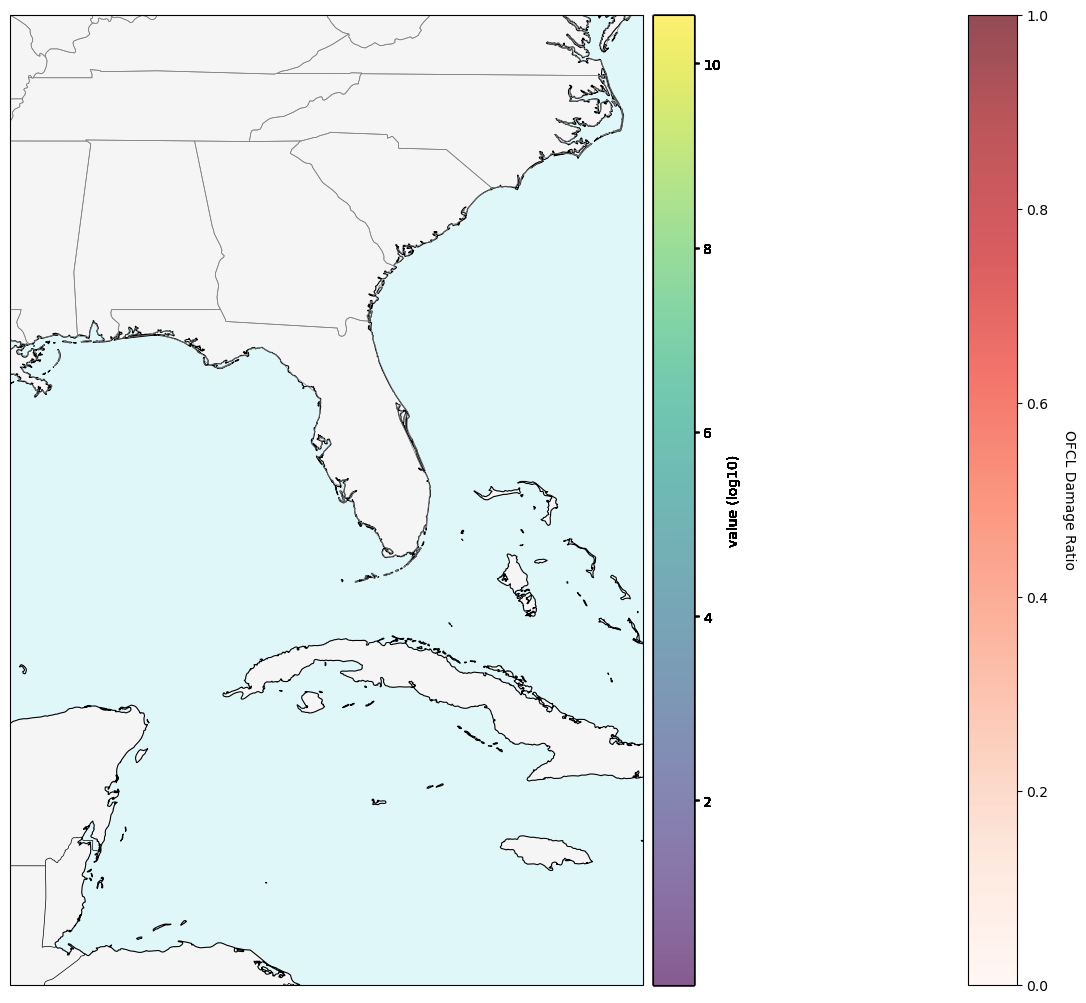

In [193]:
# Create GIF animation for Hurricane Michael (2018)
# Note: This will take some time to process all frames

import os

# Create output directory if it doesn't exist
os.makedirs('../animations', exist_ok=True)


#portfolio_SE_USA = get_country_exposure_via_api("USA", [24.5,31.0, -87.6, -80.0])
# Create and save animation as GIF
anim = animate_storm_damage(
    df_forcast, 
    portfolio_SE_USA,
    past_damages,
    history_avail, 
    timestamps=None,  # Use all timestamps
    save_path='../animations/michael_2018.gif',
    fps=2,
    figsize=(14, 10)
)

print("GIF animation saved to ../animations/michael_2018.gif")
